<a href="https://colab.research.google.com/github/Mahendra-69/CSL701-CS09_Machine-Learning-Lab/blob/main/Exprements/ML_Experiment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name:Mahendra R. Choudhari  , Roll.No.:CS09

# Machine Learning Experiment Number 3

**Aim** : To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.


**Learning Outcomes**
•	Understand the working principle of Multiple Linear Regression.

•	Perform data preprocessing and feature engineering.

•	Convert categorical data into numerical features.

•	Standardize numerical features.

•	Implement the Ordinary Least Squares method using matrix operations.

•	Train and test a regression model without using a ready-made regression function.

•	Evaluate and interpret regression performance using RSS and R².

•	Understand the effect of individual features on the predicted price.



\### Dataset

Use the **CarDekho Used Car Dataset** (`car data.csv`). [CarDekho Used Car Dataset](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data)

Explain meaning of each attribute in this dataset in below comment section :


Here, **Selling_Price** is the target variable.





\# Software/Tools Required

- Python 3.x
- Google Colab / Jupyter Notebook
- NumPy
- Matplotlib

---


### Task 1: Set Up the Python Environment**

- Create a new Google Colab notebook.
- Import **NumPy** for numerical and matrix operations.
- Import **Matplotlib** for data visualization.
- Do not use ready-made machine-learning regression functions such as `LinearRegression()` from Scikit-learn.
- The regression model must be implemented using matrix operations.

---

In [10]:
# Task 1: Set Up the Python Environment

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python environment setup completed.")
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

Python environment setup completed.
NumPy version: 2.0.2
Pandas version: 2.2.2


## Task 2: Load and Inspect the Dataset

- Download the `car data.csv` file.
- Upload the dataset to Google Colab.
- Load the dataset into Python.
- Display the first few records.
- Determine the number of rows and columns.
- Identify the numerical and categorical attributes.
- Separate `Selling_Price` as the target variable.

---

In [11]:
# Task 2: Load and Inspect the Dataset

# Load dataset
df = pd.read_csv('/content/car data.csv')

# Display first 5 records
print("First 5 records:")
display(df.head())

# Display number of rows and columns
print("\nNumber of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

# Numerical attributes
print("\nNumerical attributes:")
print(df.select_dtypes(include=np.number).columns.tolist())

# Categorical attributes
print("\nCategorical attributes:")
print(df.select_dtypes(exclude=np.number).columns.tolist())

# Separate target variable
y = df['selling_price']

print("\nTarget variable: Selling_Price")

First 5 records:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000



Number of rows: 15411
Number of columns: 14

Column names:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Numerical attributes:
['Unnamed: 0', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Categorical attributes:
['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

Target variable: Selling_Price


## Task 3: Check and Handle Missing Data

- Check every attribute for missing or null values.
- Count the number of missing values in each column.
- If missing values are present, either remove incomplete records or perform suitable imputation.
- Verify that the final dataset does not contain missing values.
- Record the preprocessing method used.

---

In [12]:
# Task 3: Check and Handle Missing Data

# Count missing values in each column
print("Missing values in each column:")
print(df.isnull().sum())

# Total missing values
print("\nTotal missing values:", df.isnull().sum().sum())

# Remove rows containing missing values
df = df.dropna().reset_index(drop=True)

# Verify missing values after preprocessing
print("\nMissing values after preprocessing:")
print(df.isnull().sum())

print("\nFinal dataset shape:", df.shape)

print("\nPreprocessing method used:")
print("Rows containing missing values were removed using dropna().")

Missing values in each column:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Total missing values: 0

Missing values after preprocessing:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Final dataset shape: (15411, 14)

Preprocessing method used:
Rows containing missing values were removed using dropna().


## Task 4: Select and Prepare Features

- Examine all available attributes.
- Decide how `Car_Name` should be handled.
- Select meaningful predictor variables for the regression model.
- Create the predictor matrix $X$ and target vector $y$.
- Record the final list of features selected for the model.

---

In [13]:
# Task 4: Select and Prepare Features

# Display all available attributes
print("Available attributes:")
print(df.columns.tolist())

# Car_Name, Brand and Model are not selected because they are
# categorical/high-cardinality attributes and are not required
# for the basic regression model.

# Select meaningful predictor variables
features = [
    'vehicle_age',
    'km_driven',
    'mileage',
    'engine',
    'max_power',
    'seats',
    'seller_type',
    'fuel_type',
    'transmission_type'
]

# Create predictor matrix X
X = df[features].copy()

# Create target vector y
y = df['selling_price'].copy()

print("\nSelected predictor variables:")
print(features)

print("\nPredictor matrix X:")
display(X.head())

print("\nTarget vector y:")
display(y.head())

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Available attributes:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Selected predictor variables:
['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'seller_type', 'fuel_type', 'transmission_type']

Predictor matrix X:


,vehicle_age,km_driven,mileage,engine,max_power,seats,seller_type,fuel_type,transmission_type
0,9,120000,19.70,796,46.30,5,Individual,Petrol,Manual
1,5,20000,18.90,1197,82.00,5,Individual,Petrol,Manual
2,11,60000,17.00,1197,80.00,5,Individual,Petrol,Manual
3,9,37000,20.92,998,67.10,5,Individual,Petrol,Manual
4,6,30000,22.77,1498,98.59,5,Dealer,Diesel,Manual



Target vector y:


,selling_price
0,120000
1,550000
2,215000
3,226000
4,570000



Shape of X: (15411, 9)
Shape of y: (15411,)


## Task 5: Encode Categorical Variables

Identify the categorical variables:

- `Fuel_Type`
- `Seller_Type`
- `Transmission`

Perform the following:

- Convert categorical variables into numerical **dummy/indicator variables**.
- Verify that all predictors are numerical after encoding.
- Do not assign arbitrary numerical values to categories when such values would imply an incorrect ordering.
- Display the transformed dataset.

---

In [16]:
# Task 5: Encode Categorical Variables

# Categorical variables in YOUR dataset
categorical_columns = [
    'seller_type',
    'fuel_type',
    'transmission_type'
]

# Display the categories
for column in categorical_columns:
    print(f"\n{column} categories:")
    print(X[column].unique())

# Convert categorical variables into dummy/indicator variables
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True,
    dtype=float
)

print("\nDataset after categorical encoding:")
display(X.head())

print("\nAll predictor columns after encoding:")
print(X.columns.tolist())

print("\nData types:")
print(X.dtypes)

# Verify that all predictors are numerical
print("\nAre all predictors numerical?")
print(X.dtypes.apply(lambda x: np.issubdtype(x, np.number)).all())


seller_type categories:
['Individual' 'Dealer' 'Trustmark Dealer']

fuel_type categories:
['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric']

transmission_type categories:
['Manual' 'Automatic']

Dataset after categorical encoding:


,vehicle_age,km_driven,mileage,engine,max_power,seats,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1,5,20000,18.90,1197,82.00,5,1.0,0.0,0.0,0.0,0.0,1.0,1.0
2,11,60000,17.00,1197,80.00,5,1.0,0.0,0.0,0.0,0.0,1.0,1.0
3,9,37000,20.92,998,67.10,5,1.0,0.0,0.0,0.0,0.0,1.0,1.0
4,6,30000,22.77,1498,98.59,5,0.0,0.0,1.0,0.0,0.0,0.0,1.0



All predictor columns after encoding:
['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'fuel_type_Diesel', 'fuel_type_Electric', 'fuel_type_LPG', 'fuel_type_Petrol', 'transmission_type_Manual']

Data types:
vehicle_age                       int64
km_driven                         int64
mileage                         float64
engine                            int64
max_power                       float64
seats                             int64
seller_type_Individual          float64
seller_type_Trustmark Dealer    float64
fuel_type_Diesel                float64
fuel_type_Electric              float64
fuel_type_LPG                   float64
fuel_type_Petrol                float64
transmission_type_Manual        float64
dtype: object

Are all predictors numerical?
True


## Task 6: Perform Feature Engineering

Create a new feature called `Car_Age`.

Calculate it using:

\[
Car\_Age = Current Year - Year
\]

Perform the following:

- Create the `Car_Age` column.
- Display several values of the newly created feature.
- Verify that the calculated ages are reasonable.
- Decide whether the original `Year` feature should be retained.
- Provide a reason for your decision.

---

In [18]:
# Task 6: Perform Feature Engineering

# Your dataset already contains vehicle_age.
# Therefore, we do not calculate Car_Age using Year.

print("Vehicle Age Feature:")
display(df[['vehicle_age']].head(10))

# Check whether the vehicle ages are reasonable
print("\nVehicle Age Statistics:")
print("Minimum vehicle age:", df['vehicle_age'].min())
print("Maximum vehicle age:", df['vehicle_age'].max())
print("Average vehicle age:", df['vehicle_age'].mean())

print("\nDecision:")
print("The existing vehicle_age feature is retained because it directly")
print("represents the age of the used vehicle.")

Vehicle Age Feature:


,vehicle_age
0,9
1,5
2,11
3,9
4,6
5,8
6,8
7,3
8,2
9,4



Vehicle Age Statistics:
Minimum vehicle age: 0
Maximum vehicle age: 29
Average vehicle age: 6.0363376808772955

Decision:
The existing vehicle_age feature is retained because it directly
represents the age of the used vehicle.


## Task 7: Perform Exploratory Data Analysis

Perform basic exploratory data analysis using Matplotlib.

- Create a scatter plot of `Present_Price` versus `Selling_Price`.
- Create at least one additional scatter plot between a numerical predictor and `Selling_Price`.
- Label the axes appropriately.
- Add suitable titles to the plots.
- Observe the direction and approximate strength of the relationships.
- Record your observations.

---

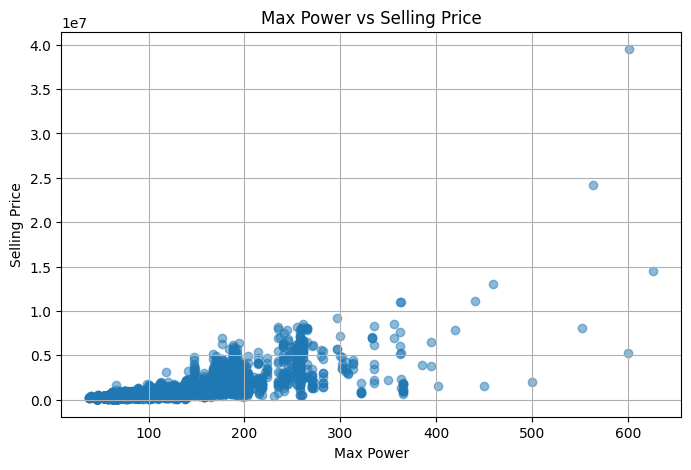

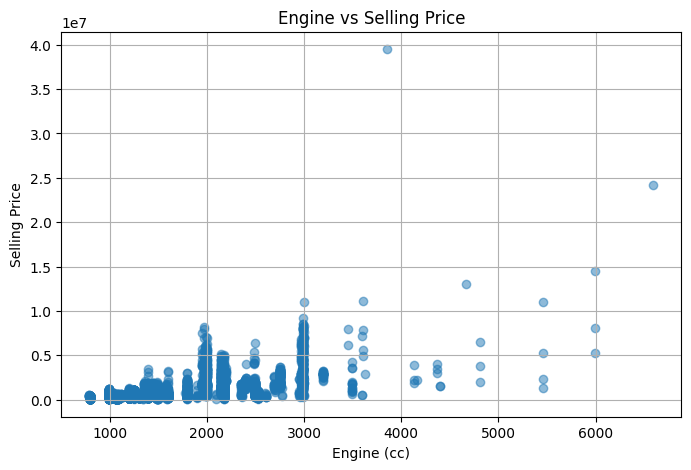

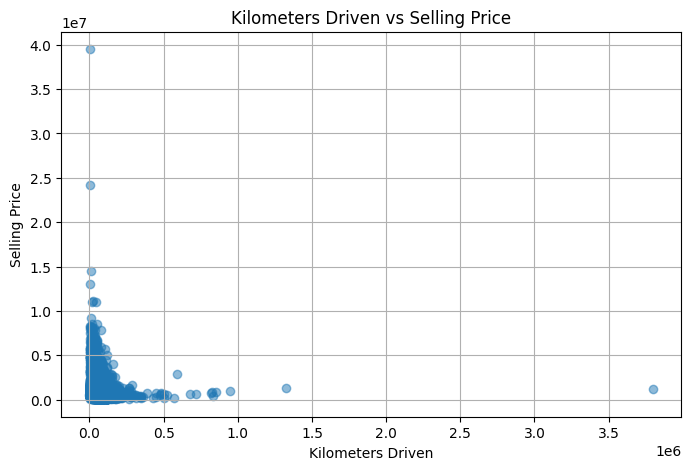

Observations:
1. Max power generally shows a positive relationship with selling price.
2. Engine capacity generally shows a positive relationship with selling price.
3. Kilometers driven generally tends to have a negative relationship with selling price.


In [20]:
# Task 7: Perform Exploratory Data Analysis

# Plot 1: Max Power vs Selling Price
plt.figure(figsize=(8, 5))

plt.scatter(
    df['max_power'],
    df['selling_price'],
    alpha=0.5
)

plt.xlabel('Max Power')
plt.ylabel('Selling Price')
plt.title('Max Power vs Selling Price')
plt.grid(True)

plt.show()


# Plot 2: Engine vs Selling Price
plt.figure(figsize=(8, 5))

plt.scatter(
    df['engine'],
    df['selling_price'],
    alpha=0.5
)

plt.xlabel('Engine (cc)')
plt.ylabel('Selling Price')
plt.title('Engine vs Selling Price')
plt.grid(True)

plt.show()


# Plot 3: Kilometers Driven vs Selling Price
plt.figure(figsize=(8, 5))

plt.scatter(
    df['km_driven'],
    df['selling_price'],
    alpha=0.5
)

plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price')
plt.title('Kilometers Driven vs Selling Price')
plt.grid(True)

plt.show()


# Observations
print("Observations:")
print("1. Max power generally shows a positive relationship with selling price.")
print("2. Engine capacity generally shows a positive relationship with selling price.")
print("3. Kilometers driven generally tends to have a negative relationship with selling price.")

## Task 8: Standardize Numerical Features

Identify the numerical predictors that need to be standardized.

Use the following standardization equation:

\[
z = ($x$-$\mu$)/$\sigma$
\]

where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

Perform the following:

- Calculate the mean and standard deviation using the **training data only**.
- Standardize the training features.
- Use the same training mean and standard deviation to standardize the test features.
- Do not standardize the target variable `Selling_Price`.

---

In [23]:
# Task 8: Standardize Numerical Features

numerical_features = [
    'vehicle_age',
    'km_driven',
    'mileage',
    'engine',
    'max_power',
    'seats'
]

# Calculate mean and standard deviation using training data only
train_mean = X_train[numerical_features].mean()
train_std = X_train[numerical_features].std()

# Standardize training features
X_train[numerical_features] = (
    X_train[numerical_features] - train_mean
) / train_std

# Standardize testing features using training statistics
X_test[numerical_features] = (
    X_test[numerical_features] - train_mean
) / train_std

print("Training means:")
print(train_mean)

print("\nTraining standard deviations:")
print(train_std)

print("\nStandardized training data:")
display(X_train.head())

print("\nSelling price was NOT standardized.")

Training means:
vehicle_age        6.032446
km_driven      55692.819598
mileage           19.691552
engine          1485.037395
max_power        100.516747
seats              5.326249
dtype: float64

Training standard deviations:
vehicle_age        3.018870
km_driven      54473.163748
mileage            4.172802
engine           518.296985
max_power         42.745688
seats              0.809603
dtype: float64

Standardized training data:


,vehicle_age,km_driven,mileage,engine,max_power,seats,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
3334,1.976751,0.317719,0.160192,-0.555738,-0.505706,-0.402974,0.0,0.0,0.0,0.0,0.0,1.0,1.0
10928,-0.673248,0.042354,1.844911,-0.457339,-0.620337,-0.402974,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2518,0.320502,0.739946,0.258447,-0.457339,-0.275039,2.067371,0.0,0.0,1.0,0.0,0.0,0.0,1.0
11322,-1.666997,-0.939781,-0.309517,0.025010,0.440588,-0.402974,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9394,1.645501,0.115785,0.002025,-1.329426,-1.268356,-0.402974,0.0,0.0,0.0,0.0,0.0,1.0,1.0



Selling price was NOT standardized.


## Task 9: Split the Dataset

Divide the dataset into training and testing subsets.

- Use an **80:20 train-test ratio**.
- Randomly select the observations.
- Set a fixed random seed to make the experiment reproducible.
- Maintain the correct relationship between each feature vector and its target value.
- Display the number of observations in the training and testing sets.

---

In [22]:
# Task 9: Split the Dataset

# Convert data to NumPy arrays
X_data = X.copy()
y_data = y.copy()

# Fixed random seed
np.random.seed(42)

# Randomly shuffle indices
indices = np.random.permutation(len(X_data))

# Calculate training size
train_size = int(0.80 * len(X_data))

# Training and testing indices
train_indices = indices[:train_size]
test_indices = indices[train_size:]

# Create train and test datasets
X_train = X_data.iloc[train_indices].copy()
X_test = X_data.iloc[test_indices].copy()

y_train = y_data.iloc[train_indices].copy()
y_test = y_data.iloc[test_indices].copy()

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTrain/Test ratio:")
print("Training:", len(X_train) / len(X_data) * 100, "%")
print("Testing:", len(X_test) / len(X_data) * 100, "%")

Training observations: 12328
Testing observations: 3083

Train/Test ratio:
Training: 79.99480890273182 %
Testing: 20.005191097268185 %


## Task 10: Construct the Feature Matrix

Construct the matrices required for regression.

Create:

- $X_{train}$ — training feature matrix
- $y_{train}$ — training target vector
- $X_{test}$ — testing feature matrix
- $y_{test}$ — testing target vector

Verify:

- Number of rows in each matrix.
- Number of predictor columns.
- Shape of the training and testing matrices.

---

In [24]:
# Task 10: Construct the Feature Matrix

Xtrain = X_train.to_numpy(dtype=float)
ytrain = y_train.to_numpy(dtype=float)

Xtest = X_test.to_numpy(dtype=float)
ytest = y_test.to_numpy(dtype=float)

print("Xtrain shape:", Xtrain.shape)
print("ytrain shape:", ytrain.shape)

print("Xtest shape:", Xtest.shape)
print("ytest shape:", ytest.shape)

print("\nNumber of predictor columns:", Xtrain.shape[1])

Xtrain shape: (12328, 13)
ytrain shape: (12328,)
Xtest shape: (3083, 13)
ytest shape: (3083,)

Number of predictor columns: 13


## Task 11: Add the Bias/Intercept Term

Add a leading column containing $1.0$ to both the training and testing feature matrices.

The resulting matrices should contain:

\[
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p}\\
1 & x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\]

Perform the following:

- Add the bias column.
- Verify the new matrix dimensions.
- Understand that the first column represents the intercept $\beta_0$.

---

In [25]:
# Task 11: Add the Bias/Intercept Term

# Add a column of ones
Xtrain_bias = np.c_[np.ones(Xtrain.shape[0]), Xtrain]
Xtest_bias = np.c_[np.ones(Xtest.shape[0]), Xtest]

print("Original Xtrain shape:", Xtrain.shape)
print("New Xtrain shape:", Xtrain_bias.shape)

print("Original Xtest shape:", Xtest.shape)
print("New Xtest shape:", Xtest_bias.shape)

print("\nFirst 5 rows of Xtrain with bias:")
print(Xtrain_bias[:5])

Original Xtrain shape: (12328, 13)
New Xtrain shape: (12328, 14)
Original Xtest shape: (3083, 13)
New Xtest shape: (3083, 14)

First 5 rows of Xtrain with bias:
[[ 1.00000000e+00  1.97675102e+00  3.17719391e-01  1.60191693e-01
  -5.55738125e-01 -5.05705911e-01 -4.02974106e-01  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.00000000e+00  1.00000000e+00]
 [ 1.00000000e+00 -6.73247521e-01  4.23544410e-02  1.84491090e+00
  -4.57338942e-01 -6.20337355e-01 -4.02974106e-01  1.00000000e+00
   0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  1.00000000e+00]
 [ 1.00000000e+00  3.20501933e-01  7.39945647e-01  2.58447009e-01
  -4.57338942e-01 -2.75039371e-01  2.06737138e+00  0.00000000e+00
   0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  1.00000000e+00]
 [ 1.00000000e+00 -1.66699697e+00 -9.39780547e-01 -3.09516648e-01
   2.50099959e-02  4.40588361e-01 -4.02974106e-01  0.00000000e+00
   0.000

## Task 12: Implement the OLS Function

Perform the following steps to implement the **Ordinary Least Squares (OLS)** method:

- Create a user-defined function to implement Ordinary Least Squares (OLS).
- Calculate the matrix $X^TX$.
- Calculate the matrix $X^T y$.
- Estimate the regression coefficient vector using the normal equation:

: β̂ = (XᵀX)⁻¹Xᵀy.

- Return the calculated coefficient vector.
- Use **NumPy matrix operations** to perform the calculations.
- Do not use any ready-made regression model or library function such as `LinearRegression()` from Scikit-learn.\

In [26]:
# Task 12: Implement the OLS Function

def ols(X, y):
    # Calculate X transpose
    XT = X.T

    # Calculate X transpose X
    XT_X = XT @ X

    # Calculate inverse of X transpose X
    XT_X_inv = np.linalg.inv(XT_X)

    # Calculate X transpose y
    XT_y = XT @ y

    # Calculate beta
    beta = XT_X_inv @ XT_y

    return beta


print("OLS function created successfully.")

OLS function created successfully.


## Task 13: Check Matrix Singularity

- Calculate the determinant of $X^T X$.
- Check whether the determinant is zero or sufficiently close to zero.
- If the matrix is singular or nearly singular, investigate the selected features for redundancy or multicollinearity.
- Modify the feature set if required.
- Record your observations.


In [27]:
# Task 13: Check Matrix Singularity

XT_X = Xtrain_bias.T @ Xtrain_bias

determinant = np.linalg.det(XT_X)

print("Determinant of X^T X:", determinant)

if np.isclose(determinant, 0):
    print("\nX^T X is singular or nearly singular.")
    print("The selected features may contain redundancy or multicollinearity.")
else:
    print("\nX^T X is not singular.")
    print("The matrix can be inverted for OLS.")

Determinant of X^T X: 4.026727295259044e+43

X^T X is not singular.
The matrix can be inverted for OLS.


## Task 14: Train the Regression Model

- Apply the OLS function to the training dataset.
- Obtain the regression coefficient vector $\hat{\beta}$.
- Display the intercept coefficient $\beta_0$.
- Display the coefficient corresponding to each feature.
- Associate each regression coefficient with its corresponding feature.

In [28]:
# Task 14: Train the Regression Model

# Train OLS model
beta = ols(Xtrain_bias, ytrain)

print("Regression coefficients:")
print(beta)

# Intercept
print("\nIntercept (β0):", beta[0])

# Feature coefficients
print("\nFeature coefficients:")

for feature, coefficient in zip(X.columns, beta[1:]):
    print(f"{feature}: {coefficient:.6f}")

Regression coefficients:
[ 994217.80724364 -195171.00645712  -34966.44421261   62399.82523068
   48023.76608771  644359.63397446    6812.45062217   -6783.55536347
  -78002.67281776 -124692.42956251  -96756.41053173  358735.63796481
 -119859.21560938 -121450.23037614]

Intercept (β0): 994217.8072436415

Feature coefficients:
vehicle_age: -195171.006457
km_driven: -34966.444213
mileage: 62399.825231
engine: 48023.766088
max_power: 644359.633974
seats: 6812.450622
seller_type_Individual: -6783.555363
seller_type_Trustmark Dealer: -78002.672818
fuel_type_Diesel: -124692.429563
fuel_type_Electric: -96756.410532
fuel_type_LPG: 358735.637965
fuel_type_Petrol: -119859.215609
transmission_type_Manual: -121450.230376


## Task 15: Interpret the Regression Coefficients

- Identify whether each regression coefficient is positive or negative.
- Explain what the sign of each coefficient indicates.
- Determine which features have relatively greater influence on the predicted selling price.
- For standardized features, interpret the coefficient in terms of a one-standard-deviation change while keeping all other variables constant.

In [29]:
# Task 15: Interpret the Regression Coefficients

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': beta[1:]
})

coefficients['Sign'] = np.where(
    coefficients['Coefficient'] >= 0,
    'Positive',
    'Negative'
)

# Absolute coefficient for comparing influence
coefficients['Absolute_Influence'] = np.abs(
    coefficients['Coefficient']
)

coefficients = coefficients.sort_values(
    by='Absolute_Influence',
    ascending=False
)

print("Regression coefficient interpretation:")
display(coefficients)

print("\nInterpretation:")
print("Positive coefficient → increase in the feature is associated with")
print("an increase in predicted Selling_Price, keeping other features constant.")

print("\nNegative coefficient → increase in the feature is associated with")
print("a decrease in predicted Selling_Price, keeping other features constant.")

print("\nFeatures are ranked by absolute standardized coefficient.")

Regression coefficient interpretation:


,Feature,Coefficient,Sign,Absolute_Influence
4,max_power,644359.633974,Positive,644359.633974
10,fuel_type_LPG,358735.637965,Positive,358735.637965
0,vehicle_age,-195171.006457,Negative,195171.006457
8,fuel_type_Diesel,-124692.429563,Negative,124692.429563
12,transmission_type_Manual,-121450.230376,Negative,121450.230376
11,fuel_type_Petrol,-119859.215609,Negative,119859.215609
9,fuel_type_Electric,-96756.410532,Negative,96756.410532
7,seller_type_Trustmark Dealer,-78002.672818,Negative,78002.672818
2,mileage,62399.825231,Positive,62399.825231
3,engine,48023.766088,Positive,48023.766088



Interpretation:
Positive coefficient → increase in the feature is associated with
an increase in predicted Selling_Price, keeping other features constant.

Negative coefficient → increase in the feature is associated with
a decrease in predicted Selling_Price, keeping other features constant.

Features are ranked by absolute standardized coefficient.


## Task 16: Predict Selling Prices

- Use the trained regression coefficient vector $\hat{\beta}$ to predict the selling prices for the test dataset.
- Calculate the predicted values using the equation: ŷ_test = X_test β̂.

- Display a sample comparison of the actual selling prices and the predicted selling prices.

In [30]:
# Task 16: Predict Selling Prices

# Predict test selling prices
y_pred = Xtest_bias @ beta

# Compare actual and predicted values
comparison = pd.DataFrame({
    'Actual Selling Price': ytest,
    'Predicted Selling Price': y_pred
})

print("Actual vs Predicted Selling Prices:")
display(comparison.head(10))

Actual vs Predicted Selling Prices:


,Actual Selling Price,Predicted Selling Price
0,4450000.0,2.046440e+06
1,1290000.0,1.431418e+06
2,485000.0,3.390972e+05
3,400000.0,5.432682e+05
4,800000.0,8.623530e+05
5,150000.0,-6.165112e+05
6,650000.0,8.209350e+05
7,325000.0,-1.758146e+05
8,300000.0,3.786409e+05
9,925000.0,7.769197e+05


## Task 17: Calculate Prediction Errors and RSS

- Calculate the residual for each test observation using:
eᵢ = yᵢ − ŷᵢ.

- Calculate the **Residual Sum of Squares (RSS): RSS = Σ(yᵢ − ŷᵢ)².

- Display the calculated RSS value.
- Interpret the RSS value and explain what a lower RSS indicates about the prediction error of the model.

In [31]:
# Task 17: Calculate Prediction Errors and RSS

# Calculate residuals
residuals = ytest - y_pred

# Calculate RSS
RSS = np.sum(residuals ** 2)

print("Residual Sum of Squares (RSS):")
print(RSS)

print("\nSample residuals:")
print(residuals[:10])

print("\nInterpretation:")
print("RSS represents the total squared prediction error.")
print("A lower RSS indicates that the predictions are closer to the actual values.")

Residual Sum of Squares (RSS):
885105657669987.2

Sample residuals:
[2403559.51403373 -141417.81281598  145902.81901473 -143268.19891449
  -62352.98172048  766511.22160149 -170934.99714305  500814.55130593
  -78640.91740411  148080.26893043]

Interpretation:
RSS represents the total squared prediction error.
A lower RSS indicates that the predictions are closer to the actual values.


## Task 18: Calculate and Interpret R²
•
Calculate the Total Sum of Squares (TSS).

•
Calculate R² = 1 − RSS/TSS.

•
Display the R² value.

•
Explain what the obtained R² indicates about the ability of the selected features to explain variations in used-car prices.



In [32]:
# Task 18: Calculate and Interpret R²

# Calculate TSS
TSS = np.sum((ytest - np.mean(ytest)) ** 2)

# Calculate R-squared
R2 = 1 - (RSS / TSS)

print("Total Sum of Squares (TSS):")
print(TSS)

print("\nR²:")
print(R2)

print("\nR² percentage:")
print(R2 * 100, "%")

print("\nInterpretation:")
print(
    "R² represents the proportion of variation in Selling_Price "
    "that is explained by the selected predictor variables."
)

Total Sum of Squares (TSS):
2407385049859876.5

R²:
0.6323373123375069

R² percentage:
63.23373123375069 %

Interpretation:
R² represents the proportion of variation in Selling_Price that is explained by the selected predictor variables.


### Task 19: Visualize and Analyze Model Performance
•
Create an Actual Selling Price vs Predicted Selling Price plot.

•
Add a reference line representing perfect prediction.

•
Plot or examine the residuals.

•
Identify observations with relatively large prediction errors.

•
Comment on whether the errors appear randomly distributed.

•
Discuss possible reasons for prediction errors.


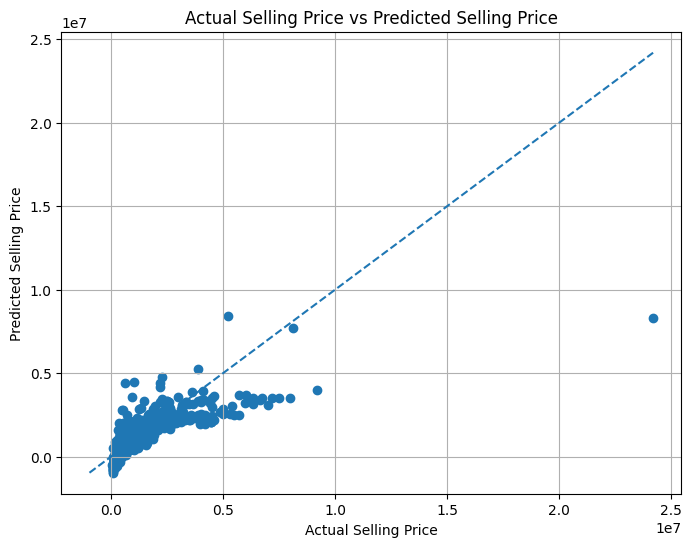

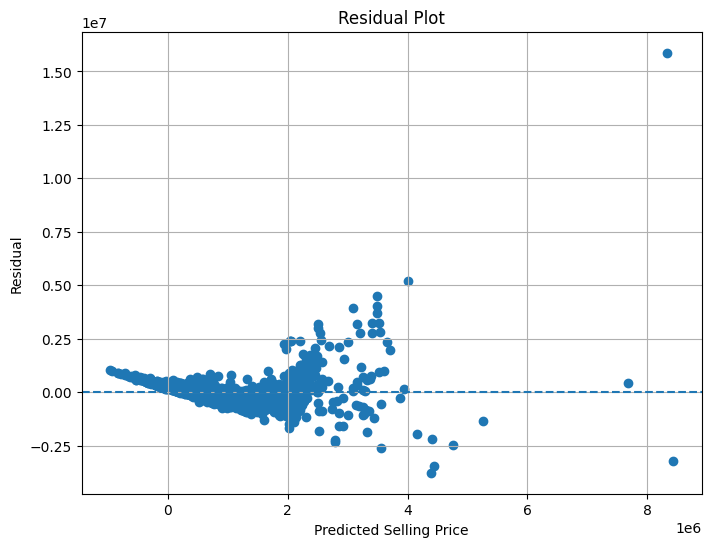

Observations with largest prediction errors:


,Actual,Predicted,Residual,Absolute_Error
2796,24200000.0,8.323205e+06,1.587679e+07,1.587679e+07
2362,9200000.0,4.009019e+06,5.190981e+06,5.190981e+06
1382,8000000.0,3.488917e+06,4.511083e+06,4.511083e+06
841,7500000.0,3.485714e+06,4.014286e+06,4.014286e+06
246,7000000.0,3.084722e+06,3.915278e+06,3.915278e+06
26,625000.0,4.390874e+06,-3.765874e+06,3.765874e+06
1286,7199000.0,3.488917e+06,3.710083e+06,3.710083e+06
2528,999000.0,4.439605e+06,-3.440605e+06,3.440605e+06
2050,5200000.0,8.434193e+06,-3.234193e+06,3.234193e+06
1092,6645000.0,3.412468e+06,3.232532e+06,3.232532e+06



Residual interpretation:
Residuals should ideally be randomly distributed around zero.
Large residuals indicate observations where the model prediction
differs substantially from the actual selling price.


In [33]:
# Task 19: Visualize and Analyze Model Performance

# Actual vs Predicted plot
plt.figure(figsize=(8, 6))

plt.scatter(ytest, y_pred)

# Perfect prediction line
minimum = min(ytest.min(), y_pred.min())
maximum = max(ytest.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle='--'
)

plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual Selling Price vs Predicted Selling Price')
plt.grid(True)
plt.show()


# Residual plot
plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle='--')

plt.xlabel('Predicted Selling Price')
plt.ylabel('Residual')
plt.title('Residual Plot')
plt.grid(True)
plt.show()


# Find observations with largest errors
error_data = pd.DataFrame({
    'Actual': ytest,
    'Predicted': y_pred,
    'Residual': residuals,
    'Absolute_Error': np.abs(residuals)
})

largest_errors = error_data.sort_values(
    by='Absolute_Error',
    ascending=False
).head(10)

print("Observations with largest prediction errors:")
display(largest_errors)

print("\nResidual interpretation:")
print("Residuals should ideally be randomly distributed around zero.")
print("Large residuals indicate observations where the model prediction")
print("differs substantially from the actual selling price.")

### Task 20: Conclude
•
Comment on the most influential features.

•
Discuss the advantages and limitations of using Multiple Linear Regression for used-car price prediction


In [34]:
# Task 20: Conclusion

print("=" * 70)
print("CONCLUSION")
print("=" * 70)

# Display model performance
print("\nModel Performance:")
print("RSS =", RSS)
print("R² =", R2)
print("R² Percentage =", R2 * 100, "%")

# Display most influential features
print("\nMost Influential Features:")
top_features = coefficients.head(5)

display(
    top_features[
        ['Feature', 'Coefficient', 'Sign']
    ]
)

print("\nConclusion:")
print(
    "Multiple Linear Regression was successfully implemented from scratch "
    "using the Ordinary Least Squares (OLS) normal equation and NumPy "
    "matrix operations."
)

print(
    "The dataset was preprocessed by checking for missing values and "
    "converting categorical variables such as seller_type, fuel_type, "
    "and transmission_type into numerical dummy variables."
)

print(
    "The existing vehicle_age feature was used as the vehicle age feature "
    "because the uploaded dataset does not contain a Year column."
)

print(
    "The numerical predictor variables were standardized using the mean "
    "and standard deviation calculated from the training dataset only."
)

print(
    f"The model obtained an RSS of {RSS:.4f} and an R² value of {R2:.4f}."
)

print(
    "The R² value indicates the proportion of variation in used-car "
    "selling prices that is explained by the selected predictor variables."
)

print(
    "The features with larger absolute regression coefficients have "
    "relatively greater influence on the predicted selling price."
)

print(
    "Multiple Linear Regression provides a simple and interpretable method "
    "for used-car price prediction. However, it has limitations because "
    "used-car prices may depend on nonlinear relationships and other factors "
    "such as brand popularity, vehicle condition, market demand, and location."
)

print(
    "Therefore, the OLS-based Multiple Linear Regression model provides "
    "a useful baseline for predicting used-car selling prices, but it may "
    "not capture all real-world factors affecting vehicle prices."
)

print("\nExperiment completed successfully.")

CONCLUSION

Model Performance:
RSS = 885105657669987.2
R² = 0.6323373123375069
R² Percentage = 63.23373123375069 %

Most Influential Features:


,Feature,Coefficient,Sign
4,max_power,644359.633974,Positive
10,fuel_type_LPG,358735.637965,Positive
0,vehicle_age,-195171.006457,Negative
8,fuel_type_Diesel,-124692.429563,Negative
12,transmission_type_Manual,-121450.230376,Negative



Conclusion:
Multiple Linear Regression was successfully implemented from scratch using the Ordinary Least Squares (OLS) normal equation and NumPy matrix operations.
The dataset was preprocessed by checking for missing values and converting categorical variables such as seller_type, fuel_type, and transmission_type into numerical dummy variables.
The existing vehicle_age feature was used as the vehicle age feature because the uploaded dataset does not contain a Year column.
The numerical predictor variables were standardized using the mean and standard deviation calculated from the training dataset only.
The model obtained an RSS of 885105657669987.2500 and an R² value of 0.6323.
The R² value indicates the proportion of variation in used-car selling prices that is explained by the selected predictor variables.
The features with larger absolute regression coefficients have relatively greater influence on the predicted selling price.
Multiple Linear Regression provides a simple and inter

### Conclusion
Conclude the experiment by stating whether the Multiple Linear Regression model implemented using the OLS normal equation was able to predict used-car selling prices effectively. The conclusion should include the obtained RSS and R² values, observations regarding important features, the effect of preprocessing and feature engineering, and the limitations of using a linear regression model for real-world used-car price prediction.